# 개요
파인튜닝 평가


5번 코드에서 생성한 테스트 데이터 평가하는 코드

```
- 비대상 테스트 데이터 : data1B, data_3B, data_8B, data_8B_Alpha
Llama-3.2-1B-Instruct_with_exec.zip
Llama-3.2-3B-Instruct_with_exec.zip
Llama-3.1-8B-Instruct_with_exec.zip
Llama-3-Alpha-Ko-8B-Instruct_with_exec.zip

너희는 나의 실수다.

- 대상 테스트 데이터 : data_1B_2, data_3B_2, data_8B_ce, data_8B_Alpha_2
Llama-3.2-1B-Instruct_with_exec2.zip
Llama-3.2-3B-Instruct_with_exec2.zip
Llama-3.1-8B-Instruct-text-to-sql-FT-olist-config-edit_with_exec.zip
Llama-3-Alpha-Ko-8B-Instruct_with_exec2.zip
`
테스트 데이터 제작 시 SQL DB 방언 sqlite 변환에 GPT-5.4 모델 사용.
configuration 재설정으로 학습률/학습 시간 증가.

- Base Model 테스트 데이터 :

```

#0. 환경설정

In [1]:
pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.5/120.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 11.9 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.8
    Uninstalling langchain-core-1.4.8:
      Successfully uninstalled langchain-core-1.4.8


In [2]:
import pandas as pd
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from tqdm import tqdm

In [3]:
import os
os.environ["OPENAI_API_KEY"] = ""

In [4]:
# 한글 폰트 설치
!apt-get install -qq fonts-nanum
!fc-cache -fv

# matplotlib 폰트 캐시 초기화
import matplotlib.font_manager as fm
import matplotlib as mpl

# 나눔고딕 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정 완료")

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

#1.데이터 불러오기

In [ ]:
# 잘못된 데이터 (gpt-4o-mini 사용해버린 모델)
# !wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/f621ee0a362638d49bc94cd4f3644e545db8e876/5.FineTuning_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec.zip
# !wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/e521c1be8768bbc4bd65d09da1d1627d5a6add32/5.FineTuning_result/Llama-3.2-3B-Instruct/Llama-3.2-3B-Instruct_with_exec.zip
# !wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/e521c1be8768bbc4bd65d09da1d1627d5a6add32/5.FineTuning_result/Llama-3.1-8B-Instruct/Llama-3.1-8B-Instruct_with_exec.zip
# !wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/6715758fb5c54ec97fbb967c6f6390ba998b0ba0/5.FineTuning_result/Llama-3-Alpha-Ko-8B-Instruct/Llama-3-Alpha-Ko-8B-Instruct_with_exec.zip

# Fine-Tuning 모델 데이터 (gpt-5.4-nano 사용)
!wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/22231b0c8f89b6b34f2d91537424c102ea510a97/5.FineTuning_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec2.zip
!wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/22231b0c8f89b6b34f2d91537424c102ea510a97/5.FineTuning_result/Llama-3.2-3B-Instruct/Llama-3.2-3B-Instruct_with_exec2.zip
!wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/8671e8d5446cdf831861d82603614d04d68681ba/5.FineTuning_result/Llama-3.1-8B-Instruct-config-edit/Llama-3.1-8B-Instruct-text-to-sql-FT-olist-config-edit_with_exec.zip
!wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/7e5fce5c41599c42f4f19d396e43f71976adfead/5.FineTuning_result/Llama-3-Alpha-Ko-8B-Instruct/Llama-3-Alpha-Ko-8B-Instruct_with_exec2.zip

--2026-07-08 00:37:58--  https://github.com/leejunho12316/LLM_FineTuning_2/raw/22231b0c8f89b6b34f2d91537424c102ea510a97/5.FineTuning_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec2.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/leejunho12316/LLM_FineTuning_2/22231b0c8f89b6b34f2d91537424c102ea510a97/5.FineTuning_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec2.zip [following]
--2026-07-08 00:37:58--  https://raw.githubusercontent.com/leejunho12316/LLM_FineTuning_2/22231b0c8f89b6b34f2d91537424c102ea510a97/5.FineTuning_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec2.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... 

In [5]:
# Base 모델 데이터 ()
!wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/c3e077efec55041e9714a7b7d06c6384e359cb90/7.BaseModel_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec.zip
!wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/c3e077efec55041e9714a7b7d06c6384e359cb90/7.BaseModel_result/Llama-3.2-3B-Instruct/Llama-3.2-3B-Instruct_with_exec.zip
!wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/c3e077efec55041e9714a7b7d06c6384e359cb90/7.BaseModel_result/Llama-3.1-8B-Instruct/Llama-3.1-8B-Instruct_with_exec.zip
!wget https://github.com/leejunho12316/LLM_FineTuning_2/raw/c3e077efec55041e9714a7b7d06c6384e359cb90/7.BaseModel_result/Llama-3-Alpha-Ko-8B-Instruct/Llama-3-Alpha-Ko-8B-Instruct_with_exec.zip

--2026-07-10 01:57:30--  https://github.com/leejunho12316/LLM_FineTuning_2/raw/c3e077efec55041e9714a7b7d06c6384e359cb90/7.BaseModel_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/leejunho12316/LLM_FineTuning_2/c3e077efec55041e9714a7b7d06c6384e359cb90/7.BaseModel_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec.zip [following]
--2026-07-10 01:57:30--  https://raw.githubusercontent.com/leejunho12316/LLM_FineTuning_2/c3e077efec55041e9714a7b7d06c6384e359cb90/7.BaseModel_result/Llama-3.2-1B-Instruct/Llama-3.2-1B-Instruct_with_exec.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connec

In [6]:
import zipfile

zip_file_path_whole = [#'Llama-3.2-1B-Instruct_with_exec.zip', 'Llama-3.2-3B-Instruct_with_exec.zip', 'Llama-3.1-8B-Instruct_with_exec.zip', 'Llama-3-Alpha-Ko-8B-Instruct_with_exec.zip',
                       #'Llama-3.2-1B-Instruct_with_exec2.zip', 'Llama-3.2-3B-Instruct_with_exec2.zip', 'Llama-3.1-8B-Instruct-text-to-sql-FT-olist-config-edit_with_exec.zip', 'Llama-3-Alpha-Ko-8B-Instruct_with_exec2.zip',
                       'Llama-3.2-1B-Instruct_with_exec.zip', 'Llama-3.2-3B-Instruct_with_exec.zip', 'Llama-3.1-8B-Instruct_with_exec.zip', 'Llama-3-Alpha-Ko-8B-Instruct_with_exec.zip' ] #Base Model 테스트 데이터
for zip_file_path in zip_file_path_whole:
  with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
      zip_ref.extractall('.')
  print(f"Extracted all contents of {zip_file_path} to current directory.")

Extracted all contents of Llama-3.2-1B-Instruct_with_exec.zip to current directory.
Extracted all contents of Llama-3.2-3B-Instruct_with_exec.zip to current directory.
Extracted all contents of Llama-3.1-8B-Instruct_with_exec.zip to current directory.
Extracted all contents of Llama-3-Alpha-Ko-8B-Instruct_with_exec.zip to current directory.


In [7]:
import pandas as pd

#잘못된 데이터
# data_1B = pd.read_csv('Llama-3.2-1B-Instruct_with_exec.csv')
# data_3B = pd.read_csv('Llama-3.2-3B-Instruct_with_exec.csv')
# data_8B = pd.read_csv('Llama-3.1-8B-Instruct_with_exec.csv')
# data_8B_Alpha = pd.read_csv('Llama-3-Alpha-Ko-8B-Instruct_with_exec.csv')

#FineTuning 모델 데이터
# data_1B_original = pd.read_csv('Llama-3.2-1B-Instruct_with_exec2.csv')
# data_3B_original = pd.read_csv('Llama-3.2-3B-Instruct_with_exec2.csv')
# data_8B_original = pd.read_csv('Llama-3.1-8B-Instruct-text-to-sql-FT-olist-config-edit_with_exec.csv')
# data_8B_Alpha_original = pd.read_csv('Llama-3-Alpha-Ko-8B-Instruct_with_exec2.csv')

#Base Model 데이터
data_1B_original = pd.read_csv('Llama-3.2-1B-Instruct_with_exec.csv')
data_3B_original = pd.read_csv('Llama-3.2-3B-Instruct_with_exec.csv')
data_8B_original = pd.read_csv('Llama-3.1-8B-Instruct_with_exec.csv')
data_8B_Alpha_original = pd.read_csv('Llama-3-Alpha-Ko-8B-Instruct_with_exec.csv')


In [8]:
#데이터 정제
data_1B = data_1B_original.copy()
data_1B = data_1B[data_1B['label_status'].str.contains('success')]

data_3B = data_3B_original.copy()
data_3B = data_3B[data_3B['label_status'].str.contains('success')]

data_8B = data_8B_original.copy()
data_8B = data_8B[data_8B['label_status'].str.contains('success')]

data_8B_Alpha = data_8B_Alpha_original.copy()
data_8B_Alpha = data_8B_Alpha[data_8B_Alpha['label_status'].str.contains('success')]

print(f"data_1B: {len(data_1B)}개")
print(f"data_3B: {len(data_3B)}개")
print(f"data_8B: {len(data_8B)}개")
print(f"data_8B_Alpha: {len(data_8B_Alpha)}개")

data_1B: 473개
data_3B: 472개
data_8B: 473개
data_8B_Alpha: 473개


#2. 결과 EDA

```
error 종류
1. success : 성공
2. success(converted) : sqlite 형식으로 변환해서 성공
3. error : SQL too long (** chars) : 비정상적으로 긴 SQL
4. error: Execution failed on sql <SQL문> : SQL문 실행 오류
5. error: wrong format (no '쿼리 작성:' prefix)
```

In [9]:
data_8B.head(3)

,index,prompt,response,label,response_tables,response_exec_result,response_status,label_tables,label_exec_result,label_status,match
0,0,<|begin_of_text|><|start_header_id|>system<|en...,"쿼리 작성: SELECT seller_city, COUNT(*) AS seller_...","쿼리 작성: SELECT LOWER(SUBSTRING(seller_city, 1, ...",sellers,"seller_city,seller_count\nsao paulo,694\ncurit...",success,sellers,"initial,seller_count\ns,1072\nc,365\nb,233\nr,...",success,False
1,1,<|begin_of_text|><|start_header_id|>system<|en...,쿼리 작성: SELECT product_id FROM products WHERE p...,쿼리 작성: SELECT product_id\nFROM products\nWHERE...,products,product_id\n1e9e8ef04dbcff4541ed26657ea517e5\n...,success,products,product_id\n005030ef108f58b46b78116f754d8d38\n...,success,False
2,2,<|begin_of_text|><|start_header_id|>system<|en...,"쿼리 작성: SELECT \n c.customer_city,\n AVG(TIME...","쿼리 작성: SELECT\n c.customer_city,\n AVG(TIMES...","customers,orders","customer_city,avg_hours_to_delivery\nabadia do...",success(converted),"customers,orders","customer_city,avg_hours_to_carrier\nonda verde...",success(converted),False


# 3. 평가1 - response_status_ratio

In [12]:
data_1B.head(3)

,index,prompt,response,label,response_tables,response_exec_result,response_status,label_tables,label_exec_result,label_status,match
0,0,<|begin_of_text|><|start_header_id|>system<|en...,"쿼리 작성: \nSELECT \n s.seller_city,\n COUNT(DI...","쿼리 작성: SELECT LOWER(SUBSTRING(seller_city, 1, ...",sellers,"seller_city,seller_count\nsao paulo,694\nsao j...",success,sellers,"initial,seller_count\ns,1072\nc,365\nb,233\nr,...",success,False
1,1,<|begin_of_text|><|start_header_id|>system<|en...,쿼리 작성:\n쿼리 작성: SELECT product_id FROM products...,쿼리 작성: SELECT product_id\nFROM products\nWHERE...,products,affected_rows=-1,success(converted),products,product_id\n005030ef108f58b46b78116f754d8d38\n...,success,False
2,2,<|begin_of_text|><|start_header_id|>system<|en...,쿼리 작성:\n쿼리 작성: \nSELECT \n AVG(TIMESTAMPDIFF(...,"쿼리 작성: SELECT\n c.customer_city,\n AVG(TIMES...","customers,orders",affected_rows=-1,success(converted),"customers,orders","customer_city,avg_hours_to_carrier\nonda verde...",success(converted),False


In [ ]:
data_1B, data_3B, data_8B, data_8B_Alpha

In [13]:
import json

# ===== 1. 카테고리 분류 함수 (이전에 만든 것 재사용) =====
def categorize_status(status: str) -> str:
    s = str(status).strip()
    if s == "success":
        return "success"
    elif s == "success(converted)":
        return "success(converted)"
    elif "SQL too long" in s:
        return "SQL too long"
    elif "wrong format" in s:
        return "wrong format"
    elif s.startswith("error"):
        return "SQL execution error"
    else:
        return "other"

# ===== 2. 모델별 비율 계산 =====
def compute_status_ratio(df):
    counts = df['response_status'].apply(categorize_status).value_counts()
    total = len(df)
    return {status: round(count / total * 100, 1) for status, count in counts.items()}

# ===== 3. 4개 모델(Base) 처리 =====
raw_data = {
    "1B":       compute_status_ratio(data_1B),
    "3B":       compute_status_ratio(data_3B),
    "8B":       compute_status_ratio(data_8B),
    "8B_Alpha": compute_status_ratio(data_8B_Alpha),
}

# ===== 4. JSON 저장 =====
output_json = "test1_response_status_ratio_base.json"   # ← 파일명은 필요에 맞게 조정
with open(output_json, "w", encoding="utf-8") as f:
    json.dump(raw_data, f, ensure_ascii=False, indent=2)

print(f"저장 완료: {output_json}")
print(json.dumps(raw_data, ensure_ascii=False, indent=2))

저장 완료: test1_response_status_ratio_base.json
{
  "1B": {
    "success(converted)": 41.6,
    "success": 31.7,
    "SQL execution error": 19.0,
    "SQL too long": 6.3,
    "wrong format": 1.3
  },
  "3B": {
    "success": 65.3,
    "success(converted)": 21.8,
    "SQL execution error": 12.5,
    "SQL too long": 0.4
  },
  "8B": {
    "success": 61.1,
    "success(converted)": 30.0,
    "SQL execution error": 8.9
  },
  "8B_Alpha": {
    "success": 56.7,
    "success(converted)": 24.9,
    "SQL execution error": 14.2,
    "SQL too long": 4.2
  }
}


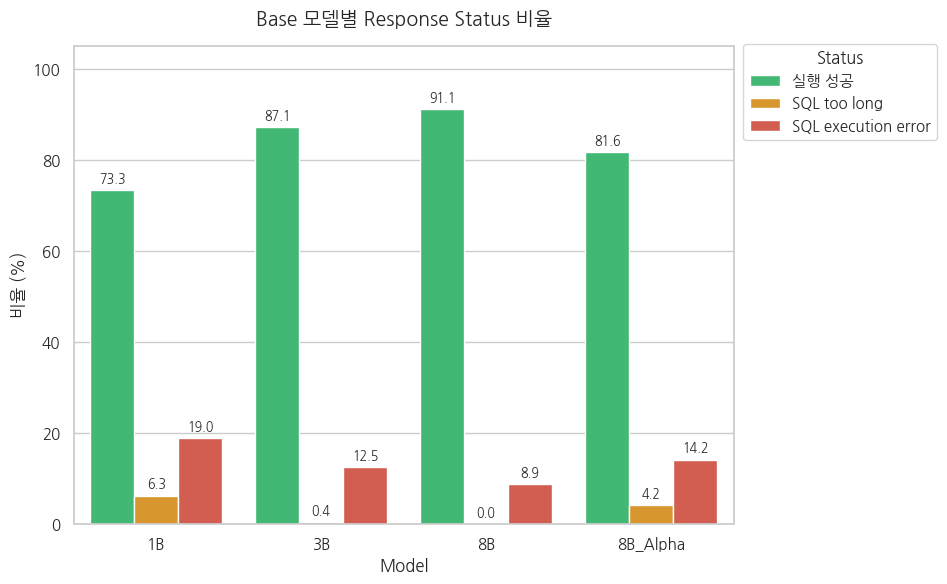

In [30]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===== 1. JSON 불러오기 =====
with open("test1_response_status_ratio_base.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# ===== 2. 카테고리 통합: success + success(converted) → 실행 성공 =====
processed = {}
for model, stats in raw_data.items():
    processed[model] = {
        "실행 성공":            round(stats.get("success", 0) + stats.get("success(converted)", 0), 1),
        "SQL too long":         stats.get("SQL too long", 0),
        "SQL execution error":  stats.get("SQL execution error", 0),
    }

# ===== 3. Seaborn용 long-format DataFrame으로 변환 =====
records = []
for model, stats in processed.items():
    for status, ratio in stats.items():
        records.append({"model": model, "status": status, "ratio": ratio})
df_plot = pd.DataFrame(records)

# ===== 4. 시각화 =====
# sns.set_theme(style="whitegrid", font="NanumGothic")
sns.set_theme(style = "whitegrid", font="NanumGothic")

fig, ax = plt.subplots(figsize=(10, 6))
palette = {
    "실행 성공":            "#2ecc71",
    "SQL too long":         "#f39c12",
    "SQL execution error":  "#e74c3c",
}

sns.barplot(
    data=df_plot,
    x="model", y="ratio", hue="status",
    palette=palette,
    ax=ax,
)


for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)

ax.set_title("Base 모델별 Response Status 비율", fontsize=14, pad=15)
ax.set_xlabel("Model")
ax.set_ylabel("비율 (%)")
ax.set_ylim(0, 105)
ax.legend(title="Status", loc="upper right", bbox_to_anchor = (1.32, 1.02))

plt.tight_layout()
plt.savefig("test1_response_status_ratio_base.png", dpi=150, bbox_inches="tight")
plt.show()

#4. 평가2 - response_tables와 label_tables 일치도 모델별로

In [16]:
import json

# ===== 1. 테이블 일치도 분석 =====
def analyze_tables_match(df):
    """
    response_tables와 label_tables의 일치 정도 분석.

    카테고리:
    - exact_match:  완전히 같음
    - subset:       response ⊂ label (부족)
    - superset:     response ⊃ label (초과)
    - overlap:      일부 겹침
    - no_match:     겹치는 테이블 없음
    - empty:        response 또는 label이 비어있음
    """
    categories = {
        "exact_match": 0,
        "subset":      0,
        "superset":    0,
        "overlap":     0,
        "no_match":    0,
        "empty":       0,
    }

    for _, row in df.iterrows():
        resp_str  = str(row.get('response_tables', '') or '')
        label_str = str(row.get('label_tables', '')  or '')

        resp_set  = set(t.strip() for t in resp_str.split(',')  if t.strip())
        label_set = set(t.strip() for t in label_str.split(',') if t.strip())

        if not resp_set or not label_set:
            categories["empty"] += 1
        elif resp_set == label_set:
            categories["exact_match"] += 1
        elif resp_set < label_set:
            categories["subset"] += 1
        elif resp_set > label_set:
            categories["superset"] += 1
        elif resp_set & label_set:
            categories["overlap"] += 1
        else:
            categories["no_match"] += 1

    total = len(df)
    return {k: round(v / total * 100, 1) for k, v in categories.items()}

# ===== 2. 모델별 분석 =====
model_dfs = {
    "1B":       data_1B,
    "3B":       data_3B,
    "8B":       data_8B,
    "8B_Alpha": data_8B_Alpha,
}

tables_match_ratio = {name: analyze_tables_match(df) for name, df in model_dfs.items()}

# ===== 3. JSON 저장 =====
output_json = "test2_tables_match_ratio_base.json"
with open(output_json, "w", encoding="utf-8") as f:
    json.dump(tables_match_ratio, f, ensure_ascii=False, indent=2)

print(f"저장 완료: {output_json}")
print(json.dumps(tables_match_ratio, ensure_ascii=False, indent=2))

저장 완료: test2_tables_match_ratio.json
{
  "1B": {
    "exact_match": 66.4,
    "subset": 26.2,
    "superset": 4.4,
    "overlap": 1.3,
    "no_match": 1.7,
    "empty": 0.0
  },
  "3B": {
    "exact_match": 76.9,
    "subset": 9.7,
    "superset": 10.8,
    "overlap": 1.7,
    "no_match": 0.8,
    "empty": 0.0
  },
  "8B": {
    "exact_match": 86.0,
    "subset": 6.8,
    "superset": 6.1,
    "overlap": 0.8,
    "no_match": 0.2,
    "empty": 0.0
  },
  "8B_Alpha": {
    "exact_match": 76.3,
    "subset": 18.8,
    "superset": 3.2,
    "overlap": 0.4,
    "no_match": 1.3,
    "empty": 0.0
  }
}


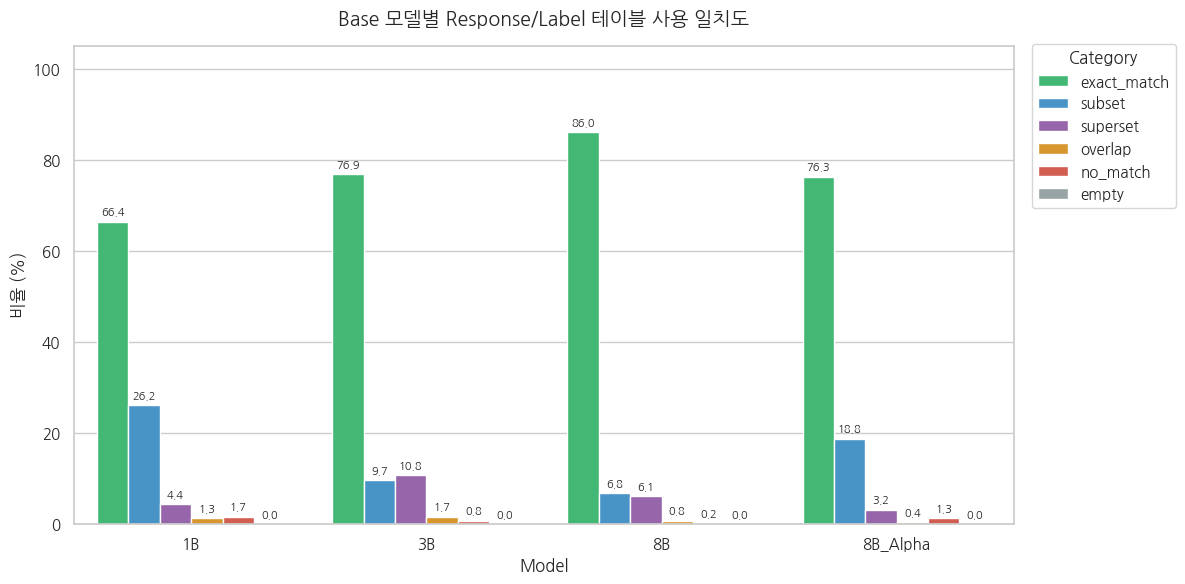

In [32]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===== 1. JSON 로드 =====
with open("test2_tables_match_ratio.json", "r", encoding="utf-8") as f:
    tables_match_ratio = json.load(f)

# ===== 2. long-format DataFrame으로 변환 =====
records = []
for model, stats in tables_match_ratio.items():
    for category, ratio in stats.items():
        records.append({"model": model, "category": category, "ratio": ratio})
df_plot = pd.DataFrame(records)

# 카테고리 순서 지정
category_order = ["exact_match", "subset", "superset", "overlap", "no_match", "empty"]

# ===== 3. 시각화 =====
# sns.set_theme(style="whitegrid", font="DejaVu Sans")
sns.set_theme(style = "whitegrid", font="NanumGothic")

fig, ax = plt.subplots(figsize=(12, 6))
palette = {
    "exact_match": "#2ecc71",  # 초록 (완벽)
    "subset":      "#3498db",  # 파랑 (부족)
    "superset":    "#9b59b6",  # 보라 (초과)
    "overlap":     "#f39c12",  # 주황 (일부)
    "no_match":    "#e74c3c",  # 빨강 (전혀)
    "empty":       "#95a5a6",  # 회색 (없음)
}

sns.barplot(
    data=df_plot,
    x="model", y="ratio", hue="category",
    hue_order=category_order,
    palette=palette,
    ax=ax,
)

# 막대 위에 값 표시
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=8)

ax.set_title("Base 모델별 Response/Label 테이블 사용 일치도", fontsize=14, pad=15)
ax.set_xlabel("Model")
ax.set_ylabel("비율 (%)")
ax.set_ylim(0, 105)
ax.legend(title="Category", loc="upper right", bbox_to_anchor=(1.18, 1.02))

plt.tight_layout()
plt.savefig("test2_tables_match_ratio_base.png", dpi=150, bbox_inches="tight")
plt.show()

#4.LLM 사용 준비

In [18]:
import re
#Llama chat template 프롬프트에서 query와 ddl 추출.
def parse_prompt(text: str) -> tuple[str, str]:

    query_match = re.search(
        r"입력 텍스트:\s*(.+?)(?=\s*\n+\s*DDL statements:|\s*$)",
        text,
        flags=re.DOTALL,
    )
    query = query_match.group(1).strip() if query_match else ""

    ddl_match = re.search(
        r"DDL statements:\s*(.+?)(?=\s*\n+\s*위의 테이블 명세)",
        text,
        flags=re.DOTALL,
    )
    ddl_statement = ddl_match.group(1).strip() if ddl_match else ""

    return query, ddl_statement

#4. LLM-as-a-Judge

##4-1. 평가3 - response 품질

In [19]:
import pandas as pd
import re
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from tqdm import tqdm

# ===== 프롬프트 정의 (전역) =====
SYSTEM_PROMPT = """
#역할
당신은 Text-to-SQL FineTuning 평가자입니다.
입력된 정보들을 보고 LLM이 올바르게 Fine Tuning 되었는지 평가해주세요.

prompt는 입력된 프롬프트, ddl_statement는 사용된 DB의 DDL문과 예시 값입니다.
response는 Fine-Tuning된 모델의 응답, label은 모범 정답입니다.

#평가 기준
1. response가 prompt의 요구사항을 충족하는지
2. response가 label과 동일한 의도/결과를 제공하는지
3. ddl statement를 보았을 때 response가 존재하는 컬럼/테이블을 참조하는지
4. response의 SQL 형식/문법이 올바른지
5. response가 prompt에서 요구하는 조건을 충족하는지 (LIMIT, ORDER BY, DISTINCT 등)

#출력 형식
평가 기준 별 만족 여부와 그 이유를 적고 만족한 평가 기준 개수로 총점을 매겨주세요.총점은 무조건 정수 하나로만 대답하세요
예시)
[평가]
1 - 만족. 이유.
2 - 불만족. 이유.
3 - 만족. 이유.
...
[총점]
4
"""

HUMAN_PROMPT = """
prompt : {prompt}
ddl_statement : {ddl_statement}
response : {response}
label : {label}
"""


def extract_score(evaluation: str) -> int | None:
    """LLM 평가 결과 텍스트에서 [총점] 뒤의 정수를 추출."""
    if not isinstance(evaluation, str):
        return None
    # [총점] 다음에 오는 첫 정수 매칭
    match = re.search(r"\[총점\]\s*(\d+)", evaluation)
    return int(match.group(1)) if match else None


def evaluate_with_llm(df: pd.DataFrame, output_csv: str, model: str = "gpt-5.4-nano") -> pd.DataFrame:
    """
    LLM으로 Fine-Tuning 결과를 평가하고 CSV로 저장.

    Args:
        df:         평가할 DataFrame (prompt, response, label 컬럼 필요)
        output_csv: 결과 저장 경로
        model:      사용할 OpenAI 모델 (기본: gpt-5.4-nano)

    Returns:
        평가 결과가 담긴 DataFrame
    """
    # 1. LLM 체인 구성
    llm = ChatOpenAI(model=model, temperature=0)
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("human",  HUMAN_PROMPT),
    ])
    chain = prompt_template | llm | StrOutputParser()

    print(f"평가 대상: {len(df)}개")

    # 2. 평가 루프
    evaluations = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="LLM 평가"):
        prompt_text, ddl_statement = parse_prompt(row['prompt'])

        try:
            evaluation = chain.invoke({
                "prompt":        prompt_text,
                "ddl_statement": ddl_statement,
                "response":      row['response'],
                "label":         row['label'],
            })
        except Exception as e:
            evaluation = f"[ERROR] {e}"

        # 총점 추출
        score = extract_score(evaluation)

        evaluations.append({
            "index":      row['index'],
            "prompt":     prompt_text,
            "ddl":        ddl_statement,
            "response":   row['response'],
            "label":      row['label'],
            "evaluation": evaluation,
            "score":      score,
        })

    # 3. 결과 저장
    df_result = pd.DataFrame(evaluations)
    df_result.to_csv(output_csv, index=False, encoding="utf-8-sig")
    print(f"\n완료: {output_csv} ({len(df_result)}개 평가 완료)")

    # 4. 간단 요약
    valid_scores = df_result['score'].dropna()
    if len(valid_scores) > 0:
        print(f"\n=== 점수 통계 ===")
        print(f"평균:   {valid_scores.mean():.2f}")
        print(f"중앙값: {valid_scores.median():.1f}")
        print(f"분포:")
        print(valid_scores.value_counts().sort_index())

    return df_result

In [20]:
result_1B = evaluate_with_llm(data_1B, "Llama-3.2-1B-Instruct_llm_eval(base).csv", model = "gpt-5.4-nano")

평가 대상: 473개


LLM 평가: 100%|██████████| 473/473 [21:49<00:00,  2.77s/it]


완료: Llama-3.2-1B-Instruct_llm_eval(base).csv (473개 평가 완료)

=== 점수 통계 ===
평균:   0.48
중앙값: 0.0
분포:
score
0    270
1    185
2     14
3      4
Name: count, dtype: int64


In [21]:
result_3B = evaluate_with_llm(data_3B, "Llama-3.2-3B-Instruct_llm_eval(base).csv", model = "gpt-5.4-nano")

평가 대상: 472개


LLM 평가: 100%|██████████| 472/472 [20:59<00:00,  2.67s/it]


완료: Llama-3.2-3B-Instruct_llm_eval(base).csv (472개 평가 완료)

=== 점수 통계 ===
평균:   1.18
중앙값: 1.0
분포:
score
0    106
1    254
2     72
3     13
4     17
5     10
Name: count, dtype: int64


In [22]:
result_8B = evaluate_with_llm(data_8B, "Llama-3.1-8B-Instruct_llm_eval(base).csv", model = "gpt-5.4-nano")

평가 대상: 473개


LLM 평가: 100%|██████████| 473/473 [20:06<00:00,  2.55s/it]


완료: Llama-3.1-8B-Instruct_llm_eval(base).csv (473개 평가 완료)

=== 점수 통계 ===
평균:   1.72
중앙값: 1.0
분포:
score
0     36
1    231
2    118
3     29
4     37
5     22
Name: count, dtype: int64


In [23]:
result_8B_Alpha = evaluate_with_llm(data_8B_Alpha, "Llama-3-Alpha-Ko-8B-Instruct_llm_eval(base).csv", model = "gpt-5.4-nano")

평가 대상: 473개


LLM 평가: 100%|██████████| 473/473 [20:21<00:00,  2.58s/it]


완료: Llama-3-Alpha-Ko-8B-Instruct_llm_eval(base).csv (473개 평가 완료)

=== 점수 통계 ===
평균:   1.45
중앙값: 1.0
분포:
score
0     75
1    243
2     93
3     15
4     23
5     24
Name: count, dtype: int64


In [28]:
import json

# ===== 데이터 정리 (제공하신 통계값 그대로) =====
data = [
    {
        "model": "Llama-3.2-1B-Instruct",
        "total_evaluated": 473,
        "mean_score": 0.48,
        "median_score": 0.0,
        "score_distribution": {
            "0": 270,
            "1": 185,
            "2": 14,
            "3": 4,
            "4": 0,
            "5": 0,
        },
    },
    {
        "model": "Llama-3.2-3B-Instruct",
        "total_evaluated": 472,
        "mean_score": 1.18,
        "median_score": 1.0,
        "score_distribution": {
            "0": 106,
            "1": 254,
            "2": 72,
            "3": 13,
            "4": 17,
            "5": 10,
        },
    },
    {
        "model": "Llama-3.1-8B-Instruct",
        "total_evaluated": 473,
        "mean_score": 1.72,
        "median_score": 1.0,
        "score_distribution": {
            "0": 36,
            "1": 231,
            "2": 118,
            "3": 29,
            "4": 37,
            "5": 22,
        },
    },
    {
        "model": "Llama-3-Alpha-Ko-8B-Instruct",
        "total_evaluated": 473,
        "mean_score": 1.61,
        "median_score": 1.0,
        "score_distribution": {
            "0": 45,
            "1": 243,
            "2": 108,
            "3": 30,
            "4": 23,
            "5": 24,
        },
    },
]

# ===== JSON 저장 =====
output_json = "test3_response_score_llm_as_a_judge_results.json"
with open(output_json, "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print(f"저장 완료: {output_json}")
print(json.dumps(data, ensure_ascii=False, indent=2))

저장 완료: test3_response_score_llm_as_a_judge_results.json
[
  {
    "model": "Llama-3.2-1B-Instruct",
    "total_evaluated": 473,
    "mean_score": 0.48,
    "median_score": 0.0,
    "score_distribution": {
      "0": 270,
      "1": 185,
      "2": 14,
      "3": 4,
      "4": 0,
      "5": 0
    }
  },
  {
    "model": "Llama-3.2-3B-Instruct",
    "total_evaluated": 472,
    "mean_score": 1.18,
    "median_score": 1.0,
    "score_distribution": {
      "0": 106,
      "1": 254,
      "2": 72,
      "3": 13,
      "4": 17,
      "5": 10
    }
  },
  {
    "model": "Llama-3.1-8B-Instruct",
    "total_evaluated": 473,
    "mean_score": 1.72,
    "median_score": 1.0,
    "score_distribution": {
      "0": 36,
      "1": 231,
      "2": 118,
      "3": 29,
      "4": 37,
      "5": 22
    }
  },
  {
    "model": "Llama-3-Alpha-Ko-8B-Instruct",
    "total_evaluated": 473,
    "mean_score": 1.61,
    "median_score": 1.0,
    "score_distribution": {
      "0": 45,
      "1": 243,
      "2": 10

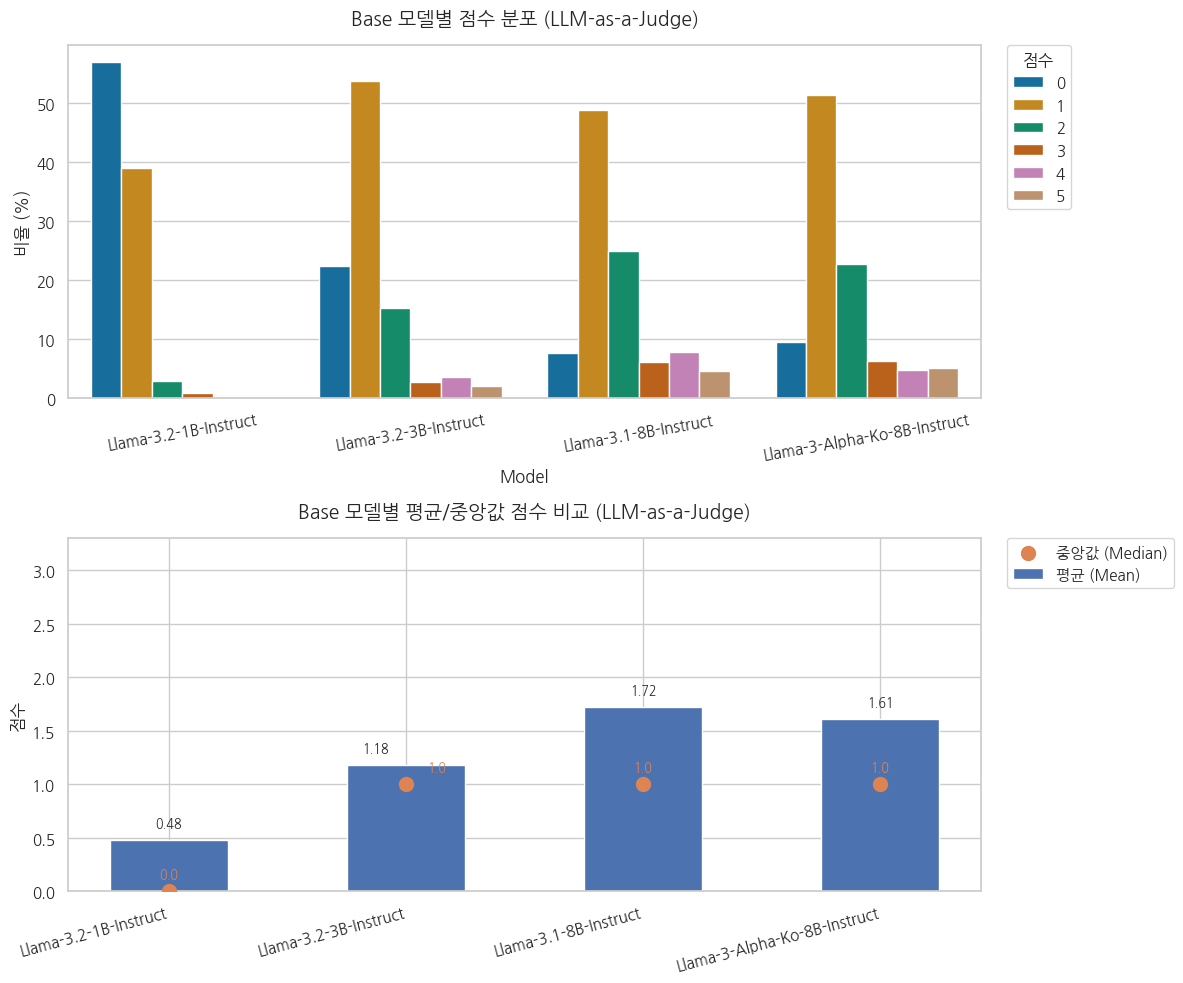

In [34]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===== 1. 데이터 로드 =====
with open("test3_response_score_llm_as_a_judge_results.json", "r", encoding="utf-8") as f:
    data = json.load(f)

sns.set_theme(style="whitegrid", font="NanumGothic")

# ===== 2. 점수 분포용 long-format DataFrame =====
records = []
for entry in data:
    model = entry["model"]
    total = entry["total_evaluated"]
    for score, count in entry["score_distribution"].items():
        records.append({
            "model": model,
            "score": score,
            "count": count,
            "pct": count / total * 100,
        })
df_dist = pd.DataFrame(records)

# ===== 3. 요약 통계 DataFrame =====
df_summary = pd.DataFrame([
    {"model": e["model"], "mean_score": e["mean_score"], "median_score": e["median_score"]}
    for e in data
])

# ===== 4. Figure: 위(분포) + 아래(평균/중앙값) =====
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- (a) 점수 분포: 모델별 그룹 바 차트 (x=model, hue=score) ---
sns.barplot(
    data=df_dist, x="model", y="pct", hue="score",
    palette="colorblind", ax=axes[0],
)
axes[0].set_title("Base 모델별 점수 분포 (LLM-as-a-Judge)", fontsize=14, pad=15)
axes[0].set_xlabel("Model")
axes[0].set_ylabel("비율 (%)")
axes[0].legend(title="점수", bbox_to_anchor=(1.02, 1.02), loc="upper left")
axes[0].tick_params(axis="x", rotation=10)

# --- (b) 모델별 평균 점수 (막대) + 중앙값 (마커) ---
x = np.arange(len(df_summary))
axes[1].bar(x, df_summary["mean_score"], color="#4c72b0", width=0.5, label="평균 (Mean)")
axes[1].scatter(x, df_summary["median_score"], color="#dd8452", s=100, zorder=5, label="중앙값 (Median)")

for i, row in df_summary.iterrows():
    # 평균/중앙값이 서로 가까우면 좌우로 벌려서 겹침 방지
    close = abs(row["mean_score"] - row["median_score"]) < 0.3
    mean_dx = -0.13 if close else 0
    median_dx = 0.13 if close else 0

    axes[1].text(i + mean_dx, row["mean_score"] + 0.12, f"{row['mean_score']:.2f}",
                 ha="center", fontsize=9)
    axes[1].text(i + median_dx, row["median_score"] + 0.12, f"{row['median_score']:.1f}",
                 ha="center", fontsize=9, color="#dd8452")

axes[1].set_xticks(x)
axes[1].set_xticklabels(df_summary["model"], rotation=15, ha="right")
axes[1].set_title("Base 모델별 평균/중앙값 점수 비교 (LLM-as-a-Judge)", fontsize=14, pad=15)
axes[1].set_ylabel("점수")
axes[1].set_ylim(0, 3.3)
axes[1].legend(bbox_to_anchor=(1.02, 1.02), loc="upper left")

plt.tight_layout()
plt.savefig("test3_score_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

##4-2. 평가4 - response & label match 여부
단순 일치로는 평가가 불가능해 LLM으로 비교 필요

대상 : response_exec_result & label_exec_result

변수명은 달라도 일단 내용은 같은 경우가 있는 것을 체크.



In [ ]:
for i in [10,20,30]:
  prompt_text, ddl_statement = parse_prompt(data_8B_Alpha['prompt'][i])
  print(prompt_text)
  print()
  print(data_8B_Alpha['response_exec_result'][i])
  print(data_8B_Alpha['label_exec_result'][i])

2017년 4분기 고객별 총 결제 금액 상위 5명과 각 고객의 해당 기간 배송 완료 주문 수

customer_id,total_payment,delivered_orders
1617b1357756262bfa56ab541c47bc16,13664.08,1
05455dfa7cd02f13d132aa7a6a9729c6,6081.54,1
46bb3c0b1a65c8399d0363cefbcc4f37,3297.3999999999996,1
0a209a88c2e3dc2981c79ad85c558059,3126.5,1
10a86619816f9d2afce3f45b04aabc71,3126.5,1

customer_id,total_payment,delivered_order_count
05455dfa7cd02f13d132aa7a6a9729c6,6081.54,1
46bb3c0b1a65c8399d0363cefbcc4f37,3297.3999999999996,2
c26acf0451e0f8ec1f5218731b9a51cf,3184.55,1
10a86619816f9d2afce3f45b04aabc71,3126.5,1
0a209a88c2e3dc2981c79ad85c558059,3126.5,1

SP와 RJ 두 주에서 모두 나타나는 고유 고객 수는 몇 명이니?

unique_customers
3

shared_unique_customers
3

2017년 12월에 구매된 주문 기준 결제수단별 구매 시각부터 결제 승인까지 평균 소요 시간과 해당 수단을 사용한 서로 다른 고객 수.

payment_type,avg_hours_to_approval,distinct_customer_count
boleto,35.762225577985426,1159
credit_card,4.355455845328496,4357
debit_card,6.645598958129995,64
voucher,11.030888131876685,220

affected_rows=-1


In [ ]:
exec_result 너무 긴거 자르기 필요


In [ ]:
4. 차이가 발생한 부분의 원인 추정
- DB 상태 변경으로 설명 가능한 차이인지 (행이 추가/삭제되어 순위가 바뀐 경우 등)
- 모델의 의도가 잘못된 경우인지 (필터링 조건/집계 방식이 본질적으로 다른 경우)

In [ ]:
import pandas as pd
import re
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from tqdm import tqdm

# ===== 프롬프트 정의 (전역) =====
SYSTEM_PROMPT = """
#역할
당신은 Text-to-SQL FineTuning 평가자입니다.
response_exec_result를 정답인 label_exec_result와 비교해 충분한 결과를 반환받았는지 평가해주세요.

prompt는 입력된 프롬프트입니다.
response_exec_result는 Fine-Tuning된 모델에 prompt를 넣고 리턴받은 SQL문을 DB에 실행한 결과입니다.
label_exec_result는 정답 SQL문을 DB에 실행한 정답 결과입니다.

#평가 기준
각 평가기준에 대해 판단할 수 없는 경우 기본 만족함으로 진행.

1. 칼럼의 일치 여부
- 칼럼명이 다르더라도 같은 정보를 표현하는가?
- 정답 칼럼을 충분히 포함하고 있는가? (예: delivered_orders vs delivered_order_count)

2. 핵심 데이터의 일치 여부
- 두 결과 사이에 겹치는 행이 충분히 존재하는가
- 겹치는 행에서 주요 수치가 유사한가 (소수점/반올림 차이는 허용)

3. 정렬 및 순서의 일관성
- prompt에 정렬 기준이 명시되어 있을 경우 동일하게 적용되었는가.
- prompt에 정렬 기준이 명시되어 있지 않다면 만족
- 동률(tie)이 있을 경우 다른 행이 선택되는 것은 허용

#판단 가이드
- 컬럼 구조와 의도가 일치하고, 결과의 대부분이 일치하면 True
- 일부 행이 다르거나 수치가 미세하게 다르더라도 의도가 일치하면 True
- 컬럼 의미 자체가 다르거나, 결과의 본질이 다르면 False

#출력 형식
[평가]
1 - 만족/불만족. 이유.
2 - 만족/불만족. 이유.
3 - 만족/불만족. 이유.

[매칭]
True 또는 False
"""

HUMAN_PROMPT = """
prompt : {prompt}
response_exec_result : {response_exec_result}
label_exec_result : {label_exec_result}
"""



In [ ]:
def extract_match(evaluation: str) -> bool | None:
    """LLM 평가 결과에서 [매칭] True/False 추출."""
    if not isinstance(evaluation, str):
        return None
    m = re.search(r"\[매칭\]\s*(True|False)", evaluation, flags=re.IGNORECASE)
    if not m:
        return None
    return m.group(1).lower() == "true"


def evaluate_match_with_llm(df: pd.DataFrame, output_csv: str, model: str = "gpt-4o-mini") -> pd.DataFrame:
    """
    LLM으로 두 SQL 실행 결과의 매칭 여부를 평가하고 CSV로 저장.

    Args:
        df:         평가할 DataFrame (prompt, response_exec_result, label_exec_result 컬럼 필요)
        output_csv: 결과 저장 경로
        model:      사용할 OpenAI 모델 (기본: gpt-4o-mini)

    Returns:
        평가 결과가 담긴 DataFrame
    """
    # 1. LLM 체인 구성
    llm = ChatOpenAI(model=model, temperature=0)
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("human",  HUMAN_PROMPT),
    ])
    chain = prompt_template | llm | StrOutputParser()

    print(f"평가 대상: {len(df)}개")

    # 2. 평가 루프
    evaluations = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="LLM 매칭 평가"):
        prompt_text, _ = parse_prompt(row['prompt'])

        try:
            evaluation = chain.invoke({
                "prompt":               prompt_text,
                "response_exec_result": row['response_exec_result'],
                "label_exec_result":    row['label_exec_result'],
            })
        except Exception as e:
            evaluation = f"[ERROR] {e}"

        # 매칭 여부 추출
        match_llm = extract_match(evaluation)

        evaluations.append({
            "index":                row['index'],
            "prompt":               prompt_text,
            "response_exec_result": row['response_exec_result'],
            "label_exec_result":    row['label_exec_result'],
            "match":                row.get('match', None),
            "evaluation":           evaluation,
            "match_llm":            match_llm,
        })

    # 3. 결과 저장
    df_result = pd.DataFrame(evaluations)
    df_result.to_csv(output_csv, index=False, encoding="utf-8-sig")
    print(f"\n완료: {output_csv} ({len(df_result)}개 평가 완료)")

    # 4. 간단 요약
    valid = df_result['match_llm'].dropna()
    if len(valid) > 0:
        print(f"\n=== 매칭 결과 ===")
        print(f"LLM 판단 True:  {(valid == True).sum()}개")
        print(f"LLM 판단 False: {(valid == False).sum()}개")
        print(f"매칭율:         {(valid == True).mean() * 100:.1f}%")

        if 'match' in df_result.columns and df_result['match'].notna().any():
            both = df_result.dropna(subset=['match', 'match_llm'])
            agree = (both['match'].astype(bool) == both['match_llm']).sum()
            print(f"\n기존 match와 일치: {agree}/{len(both)}개 ({agree/len(both)*100:.1f}%)")

    return df_result

In [ ]:
if not os.path.exists('LLM-as-a-Judge'):
    os.mkdir('LLM-as-a-Judge')

In [ ]:
data_1B, data_3B, data_8B, data_8B_Alpha에 대해 아래 코드를 다 작성해줘,

result_8b = evaluate_match_with_llm(data_8B, "LLM-as-a-Judge/Llama-3.1-8B-Instruct_match_eval.csv","gpt-5.4-nano")

In [ ]:
result_1B = evaluate_match_with_llm(
    data_1B,
    "LLM-as-a-Judge/Llama-3.2-1B-Instruct_match_eval.csv",
    "gpt-5.4-nano"
)

평가 대상: 472개


LLM 매칭 평가: 100%|██████████| 472/472 [17:27<00:00,  2.22s/it]



완료: LLM-as-a-Judge/Llama-3.2-1B-Instruct_match_eval.csv (472개 평가 완료)

=== 매칭 결과 ===
LLM 판단 True:  136개
LLM 판단 False: 286개
매칭율:         32.2%

기존 match와 일치: 329/422개 (78.0%)


In [ ]:
result_3B = evaluate_match_with_llm(
    data_3B,
    "LLM-as-a-Judge/Llama-3.2-3B-Instruct_match_eval.csv",
    "gpt-5.4-nano"
)

평가 대상: 472개


LLM 매칭 평가: 100%|██████████| 472/472 [16:54<00:00,  2.15s/it]



완료: LLM-as-a-Judge/Llama-3.2-3B-Instruct_match_eval.csv (472개 평가 완료)

=== 매칭 결과 ===
LLM 판단 True:  226개
LLM 판단 False: 200개
매칭율:         53.1%

기존 match와 일치: 296/426개 (69.5%)


In [ ]:
result_8B = evaluate_match_with_llm(
    data_8B,
    "LLM-as-a-Judge/Llama-3.1-8B-Instruct_match_eval.csv",
    "gpt-5.4-nano"
)

평가 대상: 472개


LLM 매칭 평가: 100%|██████████| 472/472 [16:10<00:00,  2.06s/it]



완료: LLM-as-a-Judge/Llama-3.1-8B-Instruct_match_eval.csv (472개 평가 완료)

=== 매칭 결과 ===
LLM 판단 True:  257개
LLM 판단 False: 184개
매칭율:         58.3%

기존 match와 일치: 301/441개 (68.3%)


In [ ]:
result_8B_Alpha = evaluate_match_with_llm(
    data_8B_Alpha,
    "LLM-as-a-Judge/Llama-3-Alpha-Ko-8B-Instruct_match_eval.csv",
    "gpt-5.4-nano"
)

평가 대상: 472개


LLM 매칭 평가: 100%|██████████| 472/472 [16:54<00:00,  2.15s/it]



완료: LLM-as-a-Judge/Llama-3-Alpha-Ko-8B-Instruct_match_eval.csv (472개 평가 완료)

=== 매칭 결과 ===
LLM 판단 True:  249개
LLM 판단 False: 178개
매칭율:         58.3%

기존 match와 일치: 274/427개 (64.2%)
